<a href="https://colab.research.google.com/github/megluc/waymo-project/blob/main/VGG_implementation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub


gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


In [8]:
# download the dataset
path = kagglehub.dataset_download("marquis03/bdd100k-scenario-classification")
print("Dataset path:", path)

Using Colab cache for faster access to the 'bdd100k-scenario-classification' dataset.
Dataset path: /kaggle/input/bdd100k-scenario-classification


In [9]:
# loading and splitting the dataset

img_size = (160, 160)
batch_size = 32

# Training set (70%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, "train"),
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# Validation set (30%)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, "train"),
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# Test set (separate folder)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, "val"),
    image_size=img_size,
    batch_size=batch_size
)

Found 69863 files belonging to 7 classes.
Using 48905 files for training.
Found 69863 files belonging to 7 classes.
Using 20958 files for validation.
Found 10000 files belonging to 7 classes.


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.shuffle(200).prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [11]:
def build_vgg(input_shape=(160, 160, 3), num_classes=7):

    model = models.Sequential([

        # ✅ Explicit input layer (BEST PRACTICE)
        layers.Input(shape=input_shape),

        # Augmentation
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        # Normalization
        layers.Rescaling(1./255),

        # Block 1
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Block 4
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ])

    return model

In [13]:
#create the model
model = build_vgg()


model.build((None, 160, 160, 3))

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model structure
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 160, 160, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 40, 40, 128)    │       147,58

 Total params: 1,192,999 (4.55 MB)

 Trainable params: 1,191,079 (4.54 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [14]:
#train the model
history = vgg_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)


Epoch 1/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 431s 251ms/step - accuracy: 0.6457 - loss: 0.9293 - val_accuracy: 0.6164 - val_loss: 1.4189
Epoch 2/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 338s 209ms/step - accuracy: 0.6823 - loss: 0.8281 - val_accuracy: 0.6900 - val_loss: 0.8110
Epoch 3/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 382s 209ms/step - accuracy: 0.6924 - loss: 0.7959 - val_accuracy: 0.6934 - val_loss: 0.9934
Epoch 4/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 336s 208ms/step - accuracy: 0.7012 - loss: 0.7729 - val_accuracy: 0.6566 - val_loss: 0.9180
Epoch 5/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 364s 197ms/step - accuracy: 0.7062 - loss: 0.7537 - val_accuracy: 0.6367 - val_loss: 0.9378
Epoch 6/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 340s 209ms/step - accuracy: 0.7120 - loss: 0.7421 - val_accuracy: 0.6949 - val_loss: 0.7997
Epoch 7/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 335s 208ms/step - accuracy: 0.7139 - loss: 0.7301 - val_accuracy: 0.7072 - val_loss: 0.8976
Epoch 8/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 329s 203ms/step - ac

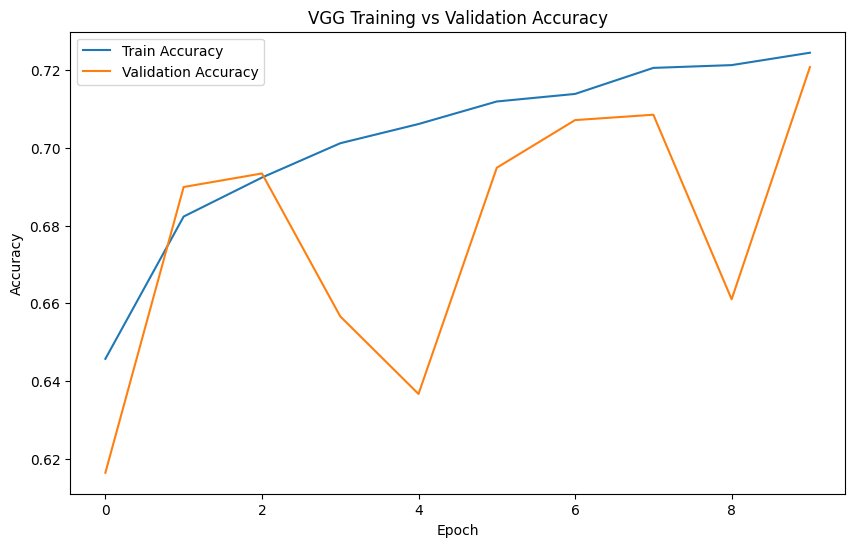

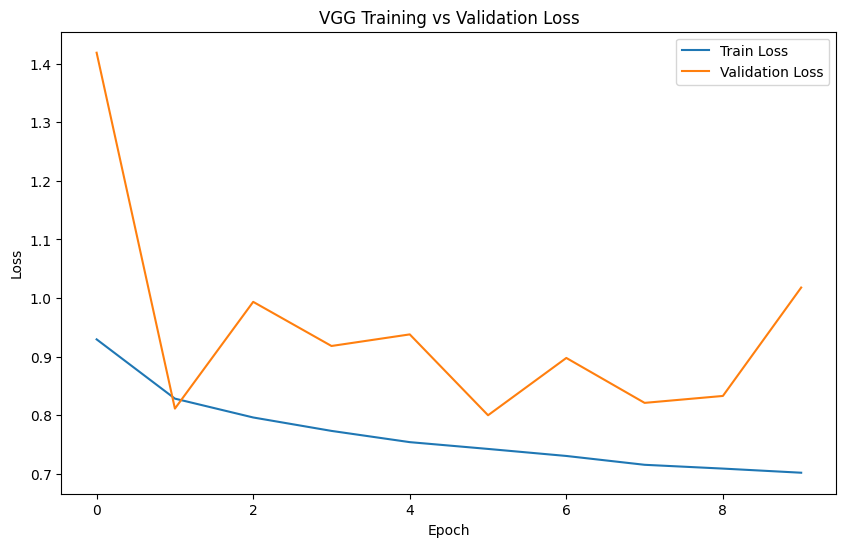

In [15]:
# plot accuracy and loss
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

# Accuracy plot
plt.figure(figsize=(10,6))
plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
plt.plot(hist['epoch'], hist['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGG Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(10,6))
plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
plt.plot(hist['epoch'], hist['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VGG Training vs Validation Loss')
plt.legend()
plt.show()


In [16]:
# evaluate model
test_loss, test_acc = vgg_model.evaluate(test_dataset)
print("VGG Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.7077 - loss: 1.0745
VGG Test Accuracy: 0.7077000141143799
